In [1]:
from telescope_reduction import *

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({'axes.linewidth' : 1.5,
                     'ytick.major.width' : 1.5,
                     'ytick.minor.width' : 1.5,
                     'xtick.major.width' : 1.5,
                     'xtick.minor.width' : 1.5,
                     'xtick.labelsize': 12, 
                     'ytick.labelsize': 12,
                     'axes.labelsize': 18,
                     'axes.labelpad' : 5,
                     'axes.titlesize' : 20,
                     'axes.titlepad' : 10,
                     'font.family': 'Serif'
                    })

mpl.rcParams['mathtext.fontset'] = 'cm'          # Computer Modern serif
mpl.rcParams['mathtext.rm'] = 'serif'

In [3]:
# all filters: 'UVIS1 FQ619N'  'UVIS2 F467M'  'UVIS2 F547M'  'UVIS2 F657N'  'UVIS2 F763M'  'UVIS2 F845M'  'UVIS2 FQ727N'
folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F845M"
hst_list = fits_to_list(folder, "EXPSTART", "RA_TARG", "DEC_TARG", "ORIENTAT")

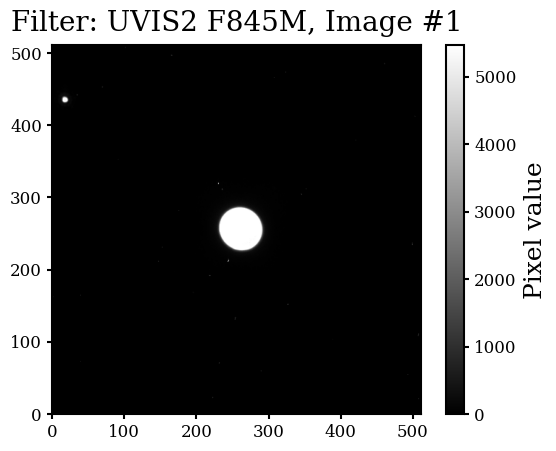

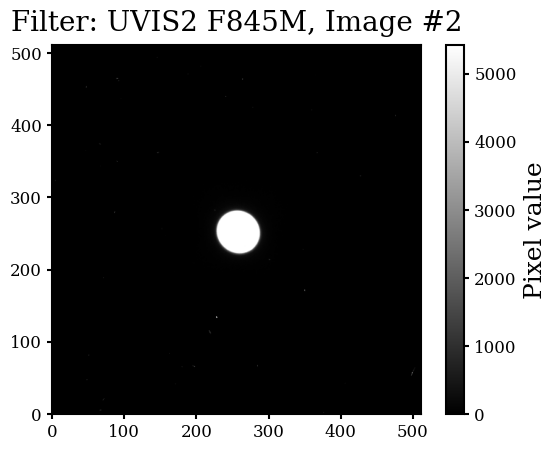

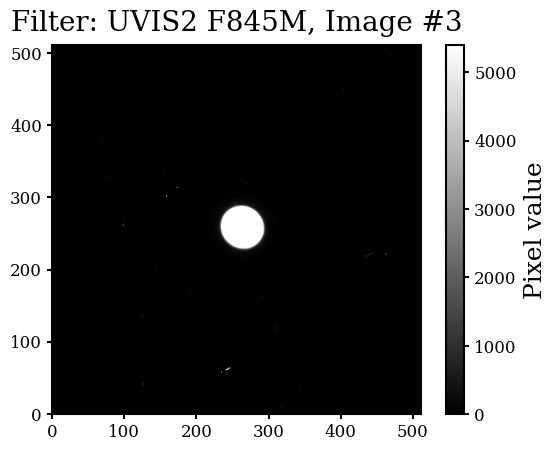

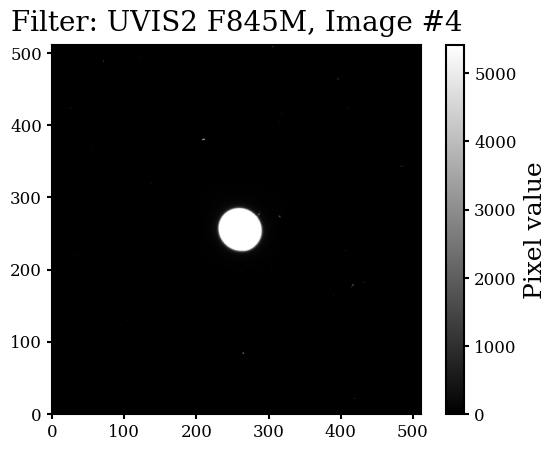

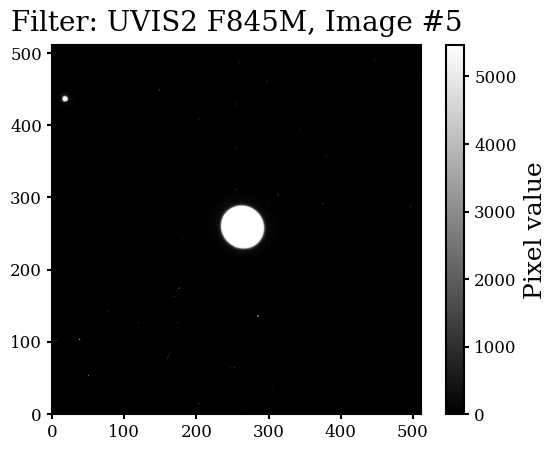

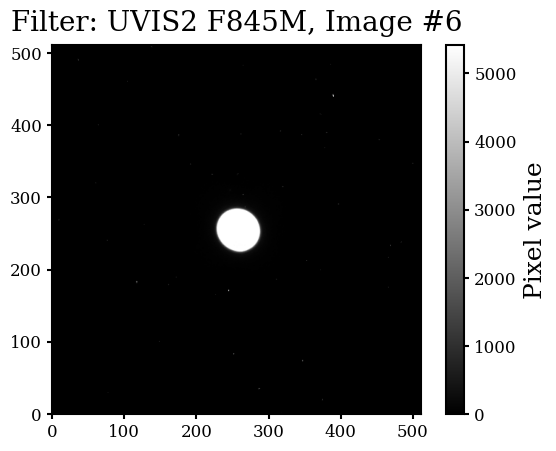

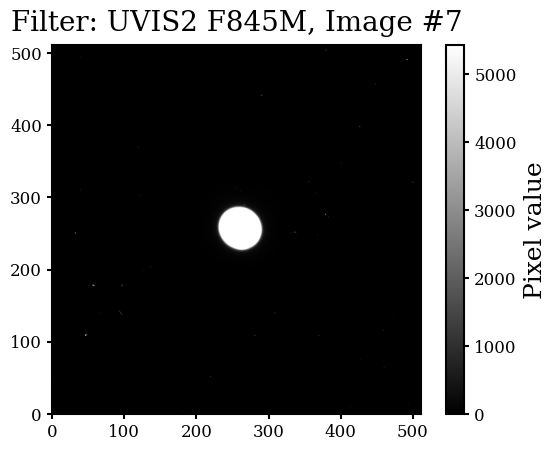

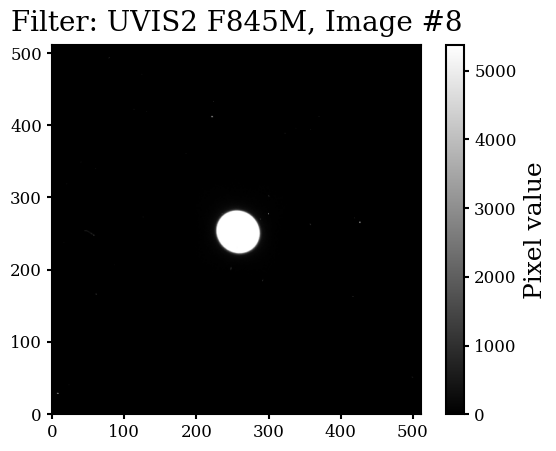

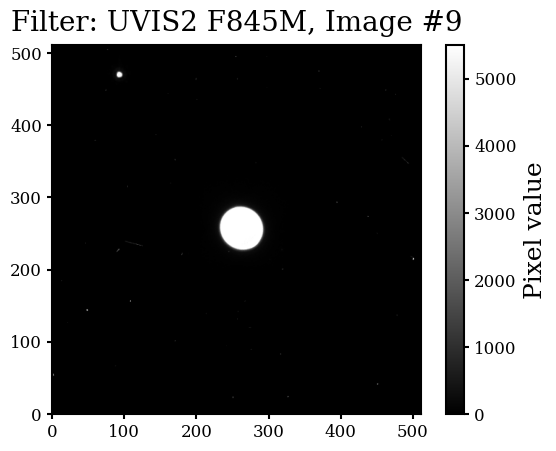

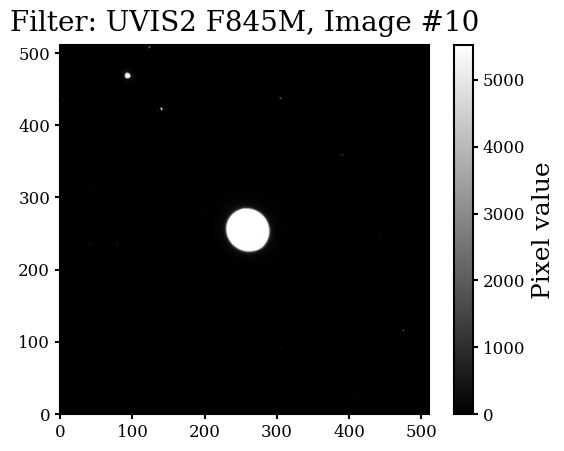

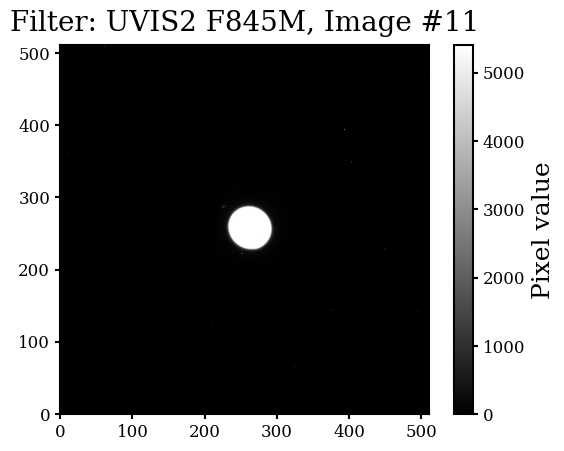

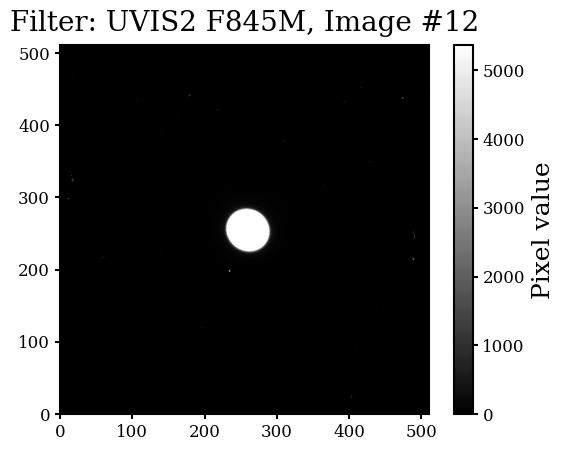

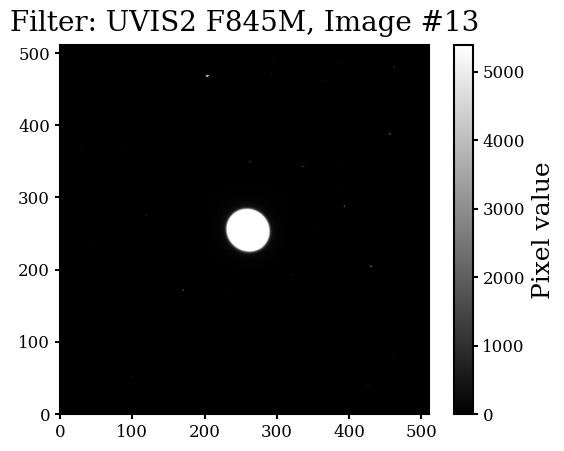

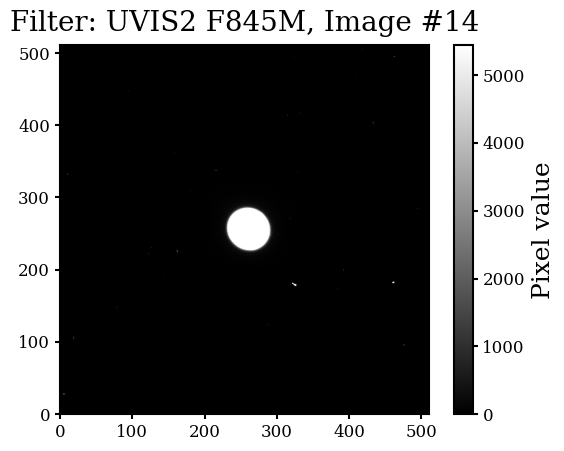

In [16]:
hst_images = [entry['data'] for entry in hst_list]
show_image_list(hst_images, filter_name="UVIS2 F845M", automatic_vrange=False)

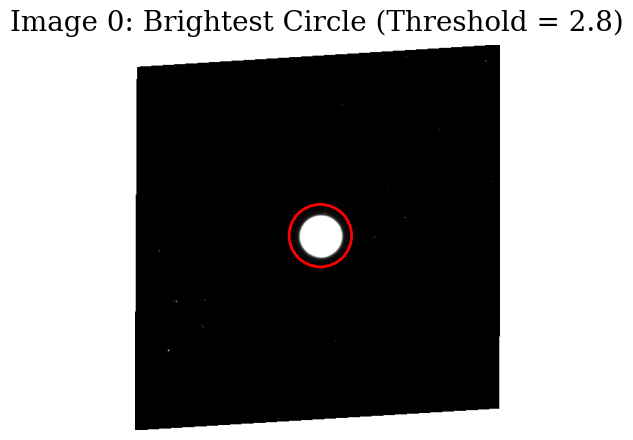

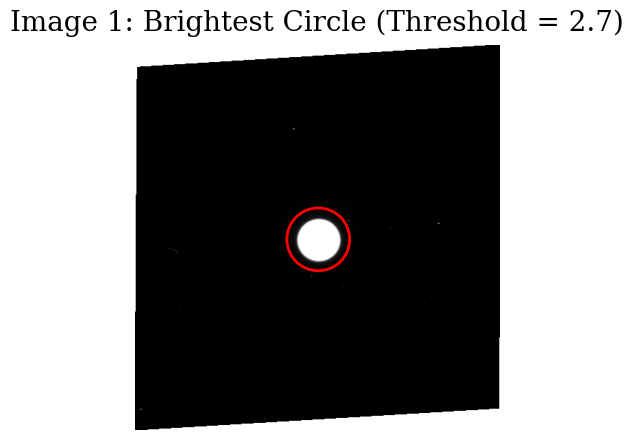

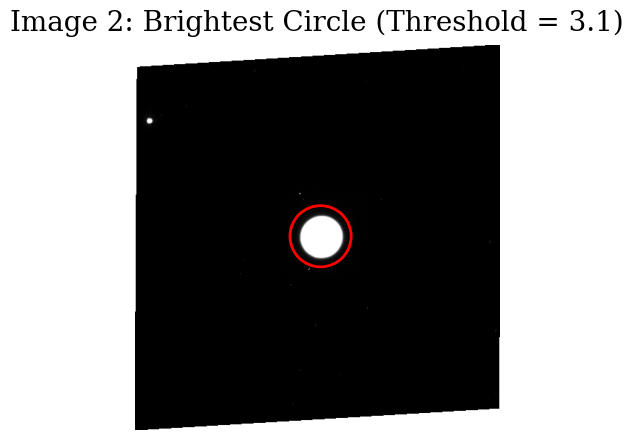

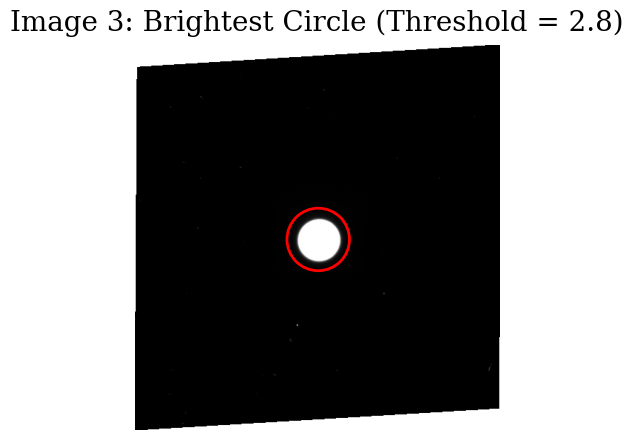

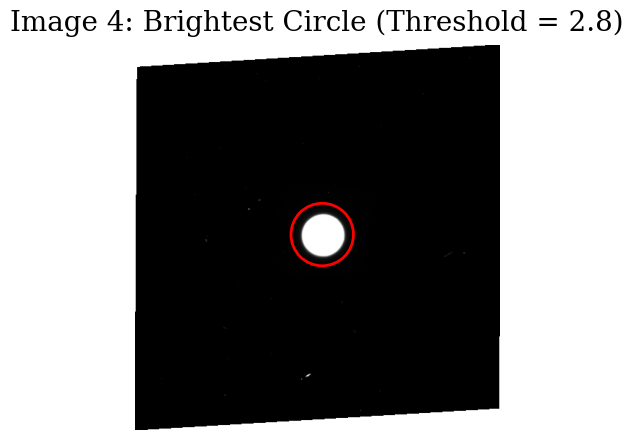

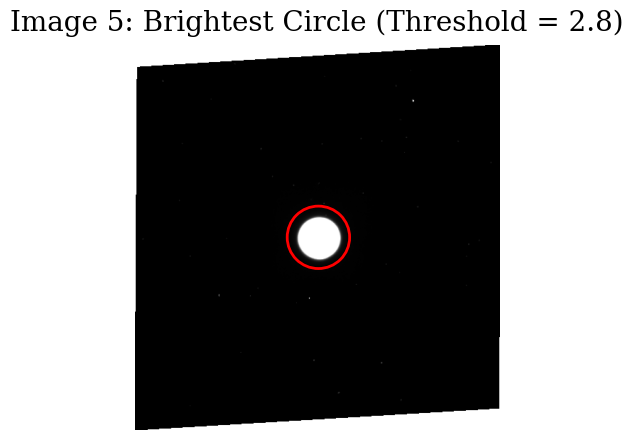

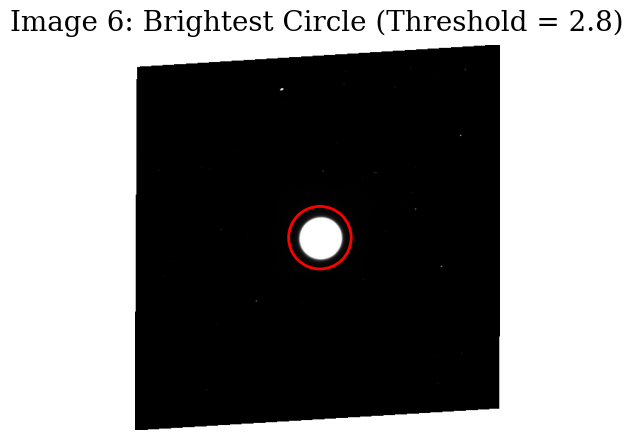

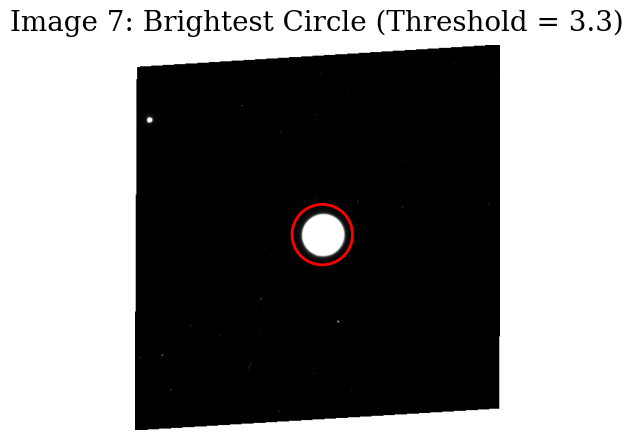

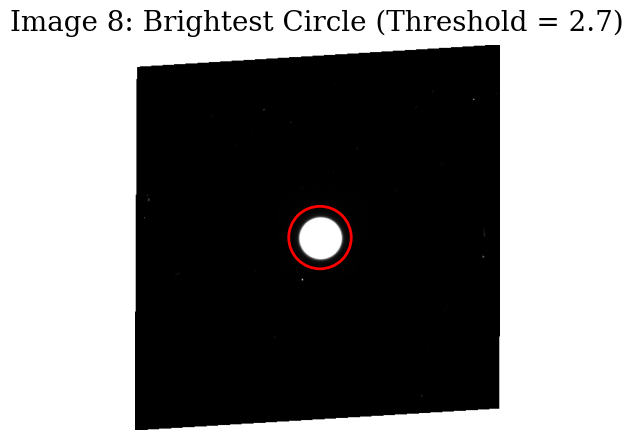

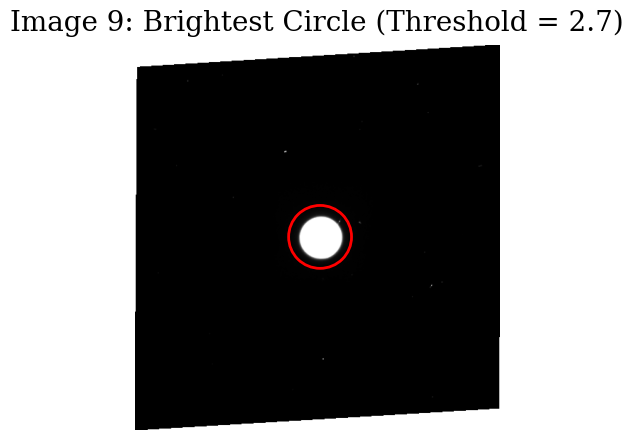

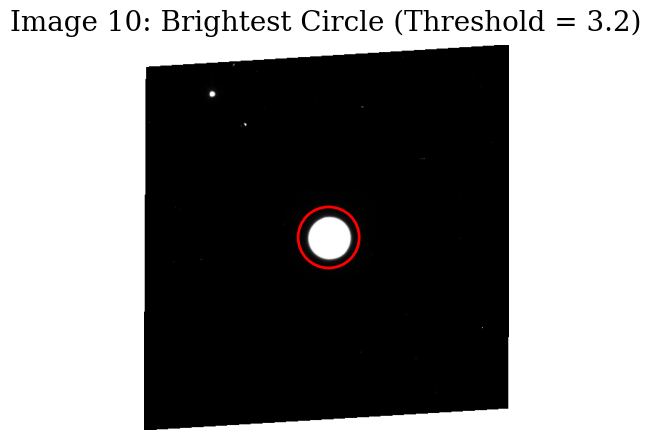

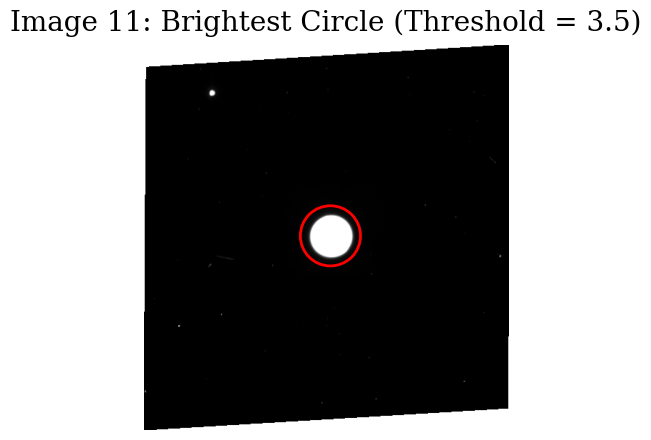

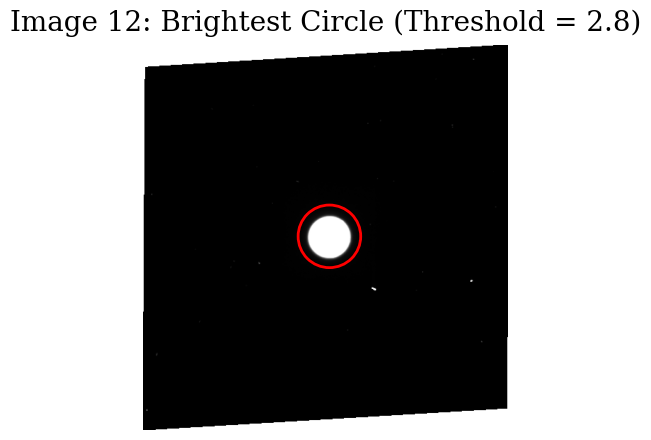

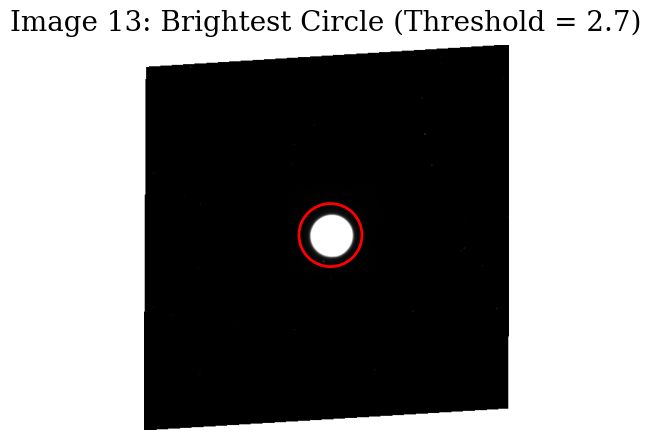

In [26]:
results_F845M = draw_largest_bright_circle(hst_images, use_adaptive_threshold=False,
                                percentile_threshold=98,
                                radius_scale=1.1, show=True)

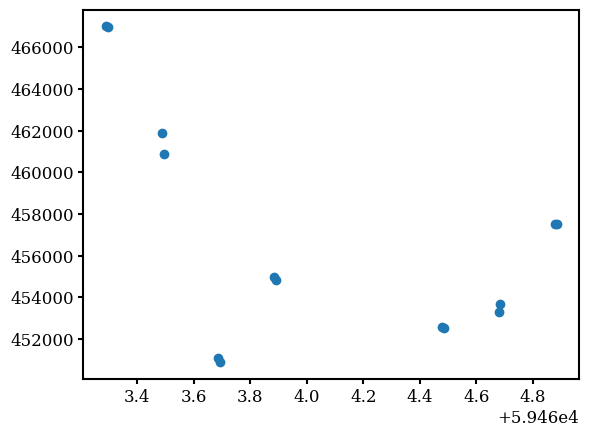

In [27]:
import matplotlib.pyplot as plt

hst_times = [entry['mjd'] for entry in hst_list]
fluxes = [entry['flux'] for entry in results_F845M]

plt.scatter(hst_times, fluxes)

In [7]:
def process_many_filters(folder, filter_list):
    hst_masterlist = []
    result_masterlist = []

    for filter_name in filter_list:
        hst_list = fits_to_list(folder + filter_name, "EXPSTART", "RA_TARG", "DEC_TARG", "ORIENTAT")
        hst_images = [entry['data'] for entry in hst_list]
        results = draw_largest_bright_circle(hst_images, use_adaptive_threshold=False,
                                percentile_threshold=98,
                                radius_scale=1.1, show=True)
        
        hst_masterlist.append(hst_list)
        result_masterlist.append(results)

    return hst_masterlist, result_masterlist
        

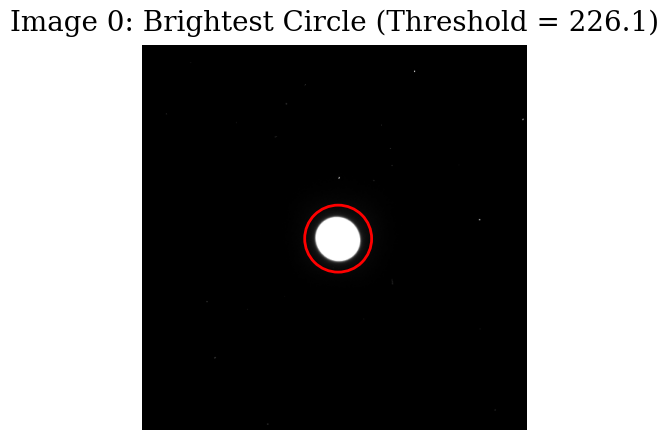

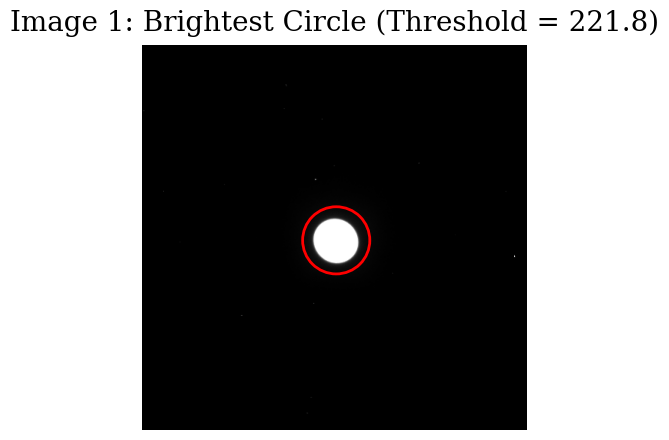

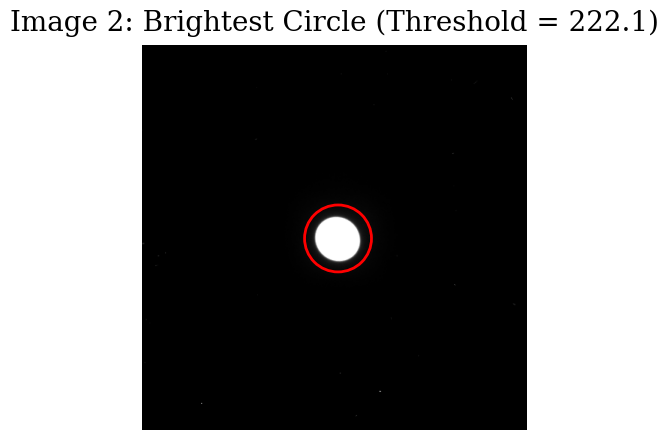

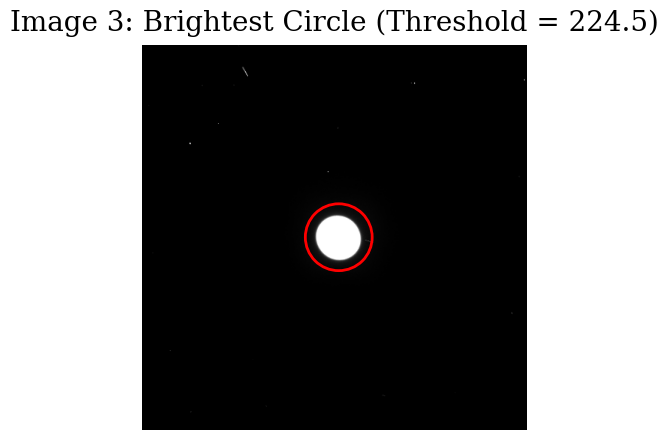

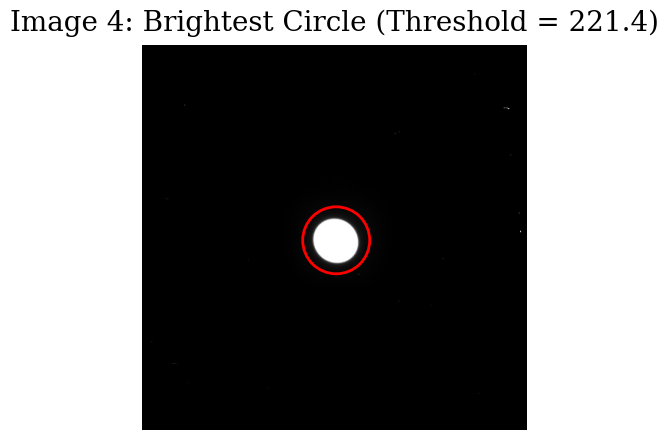

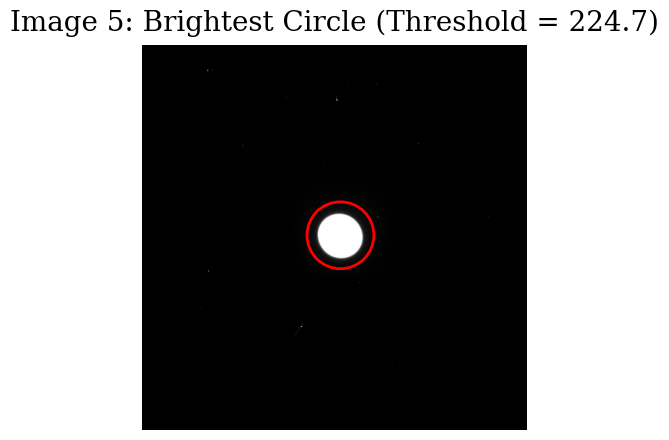

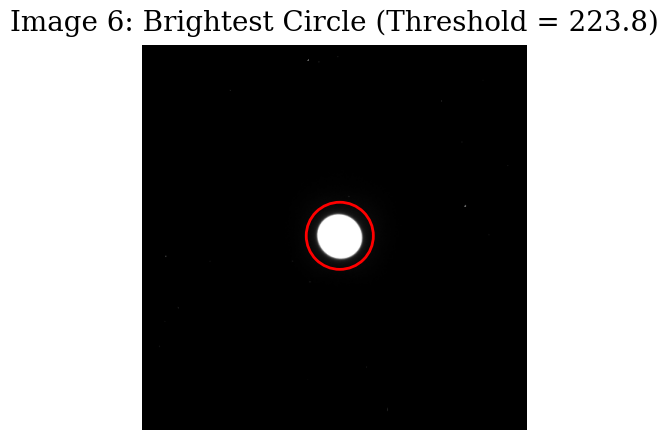

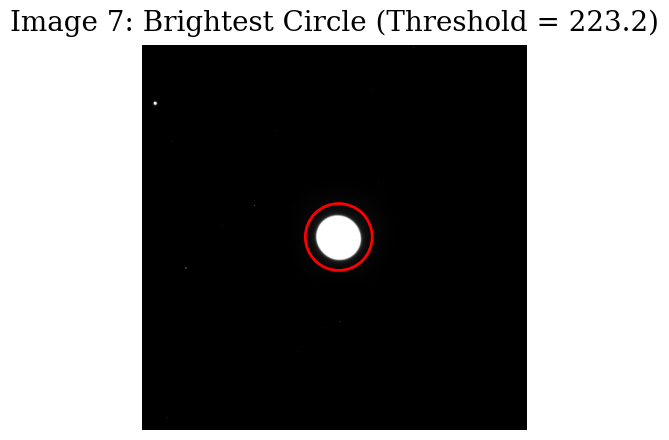

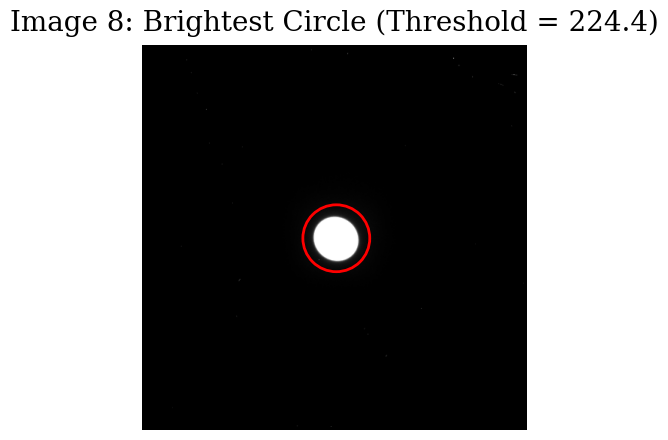

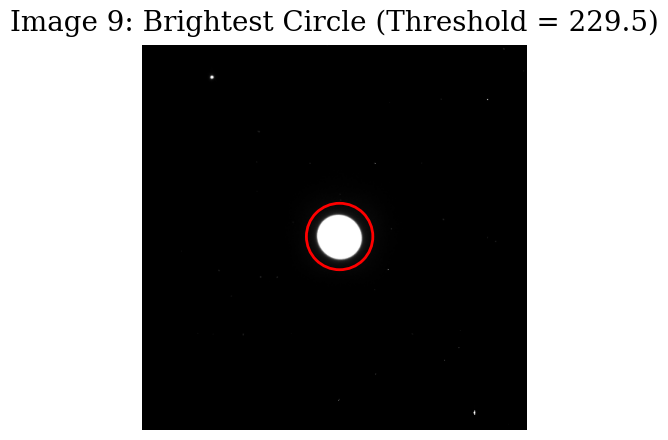

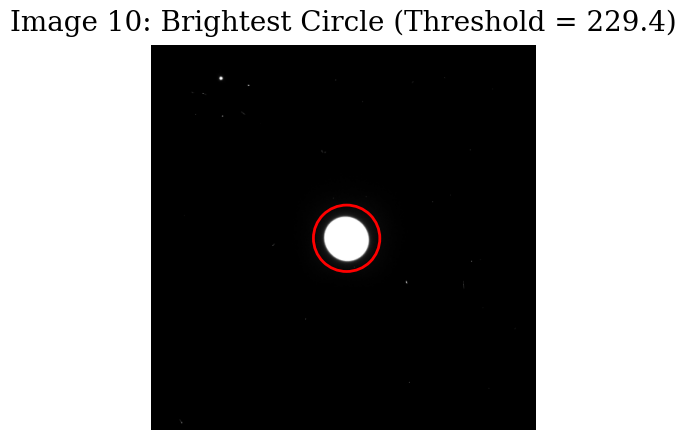

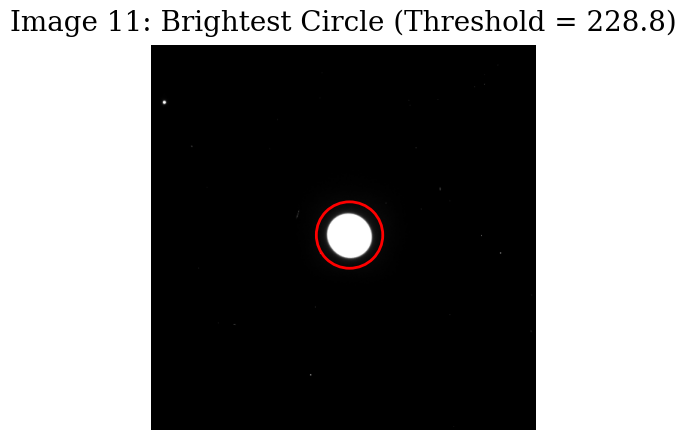

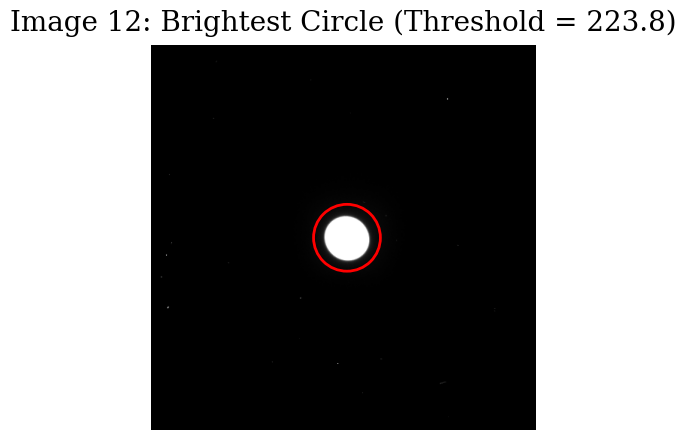

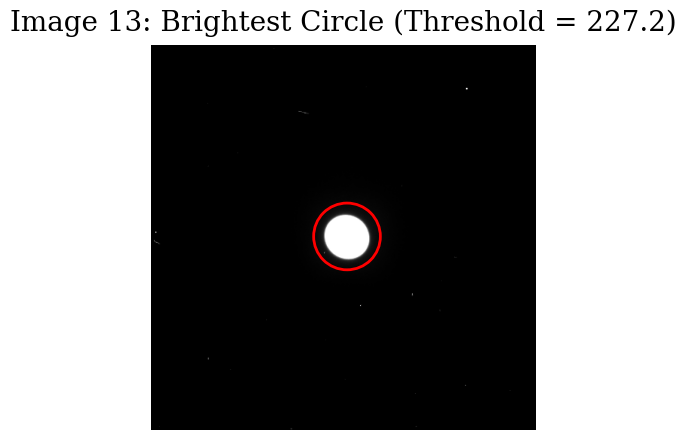

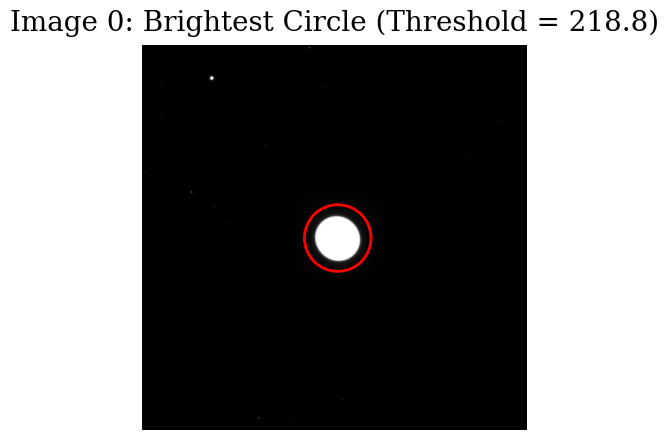

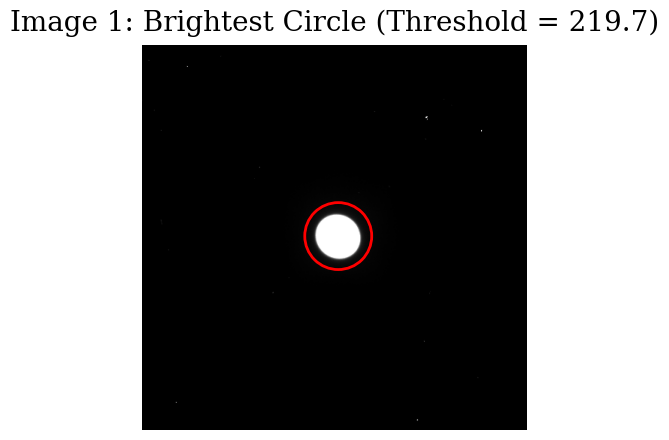

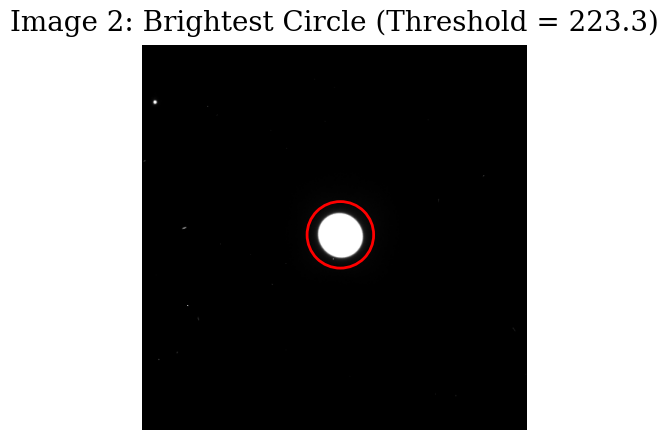

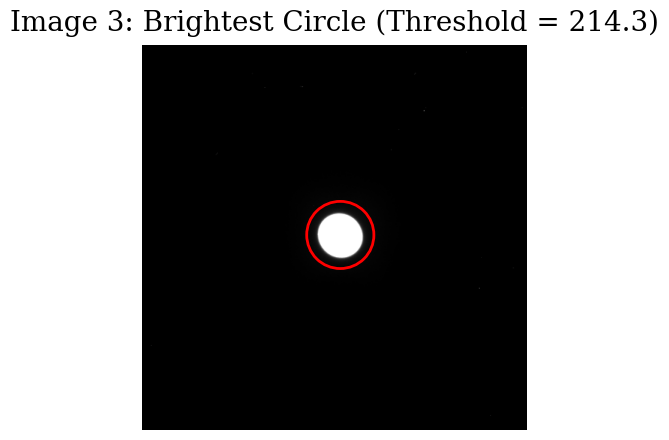

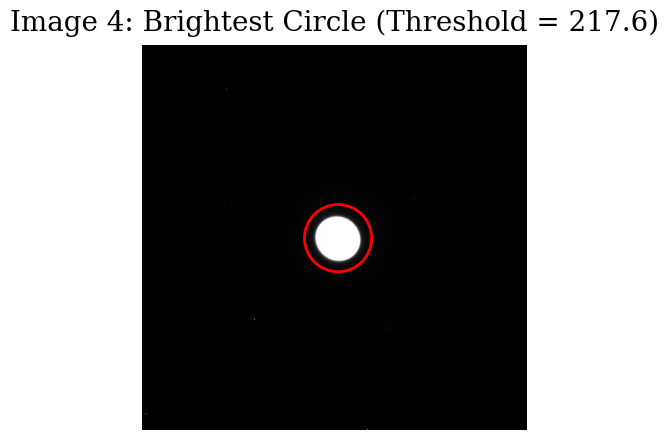

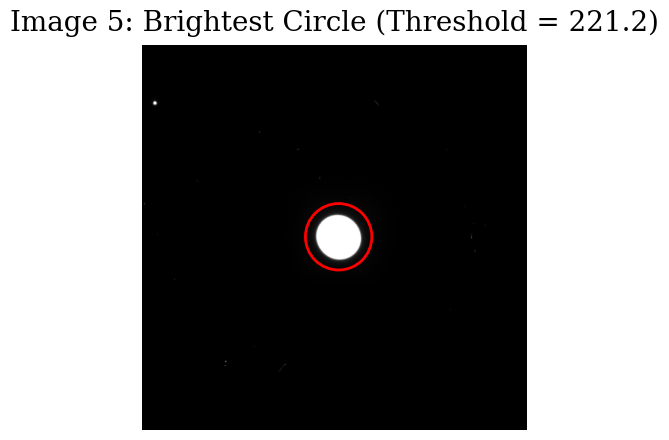

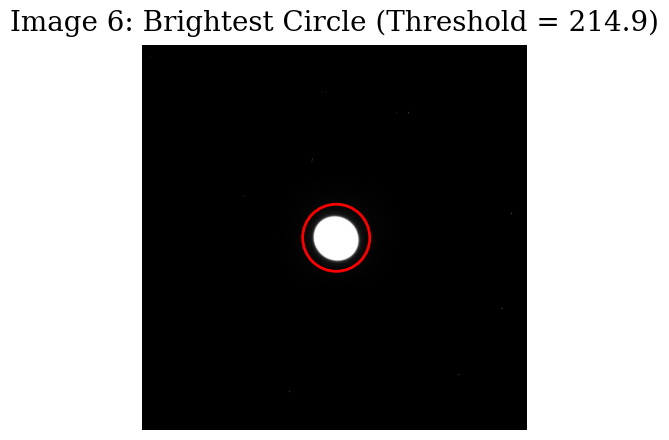

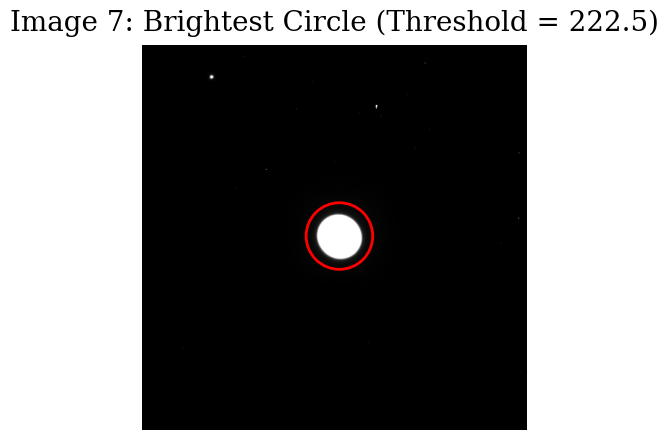

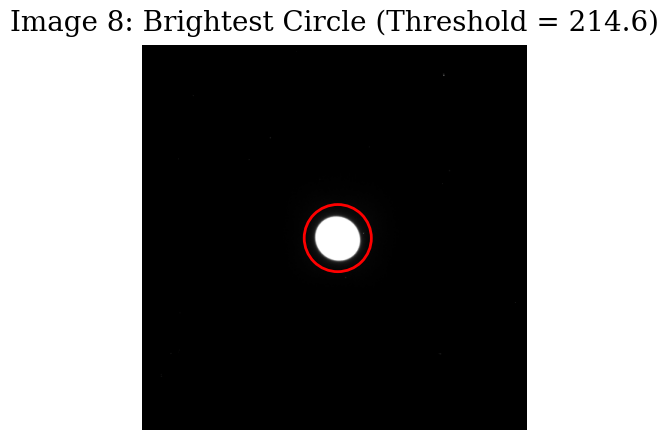

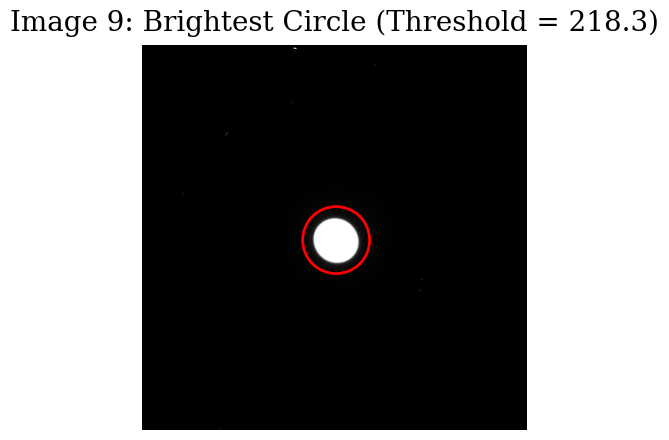

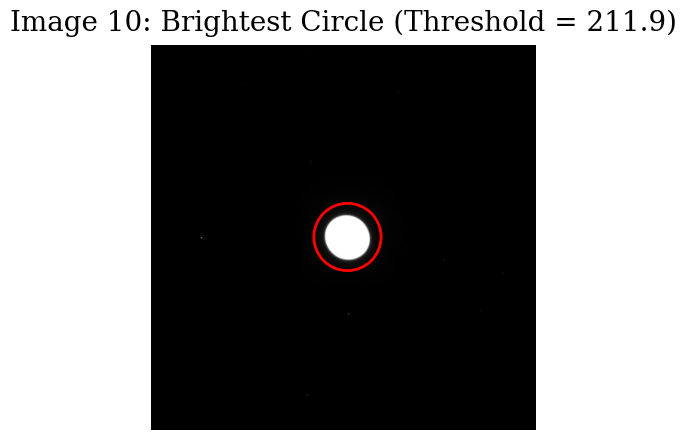

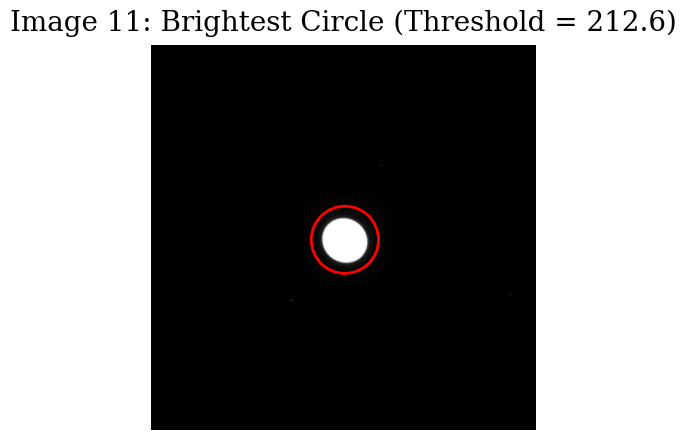

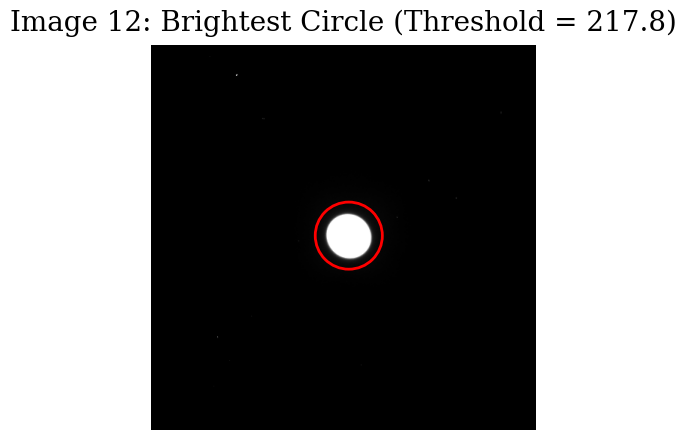

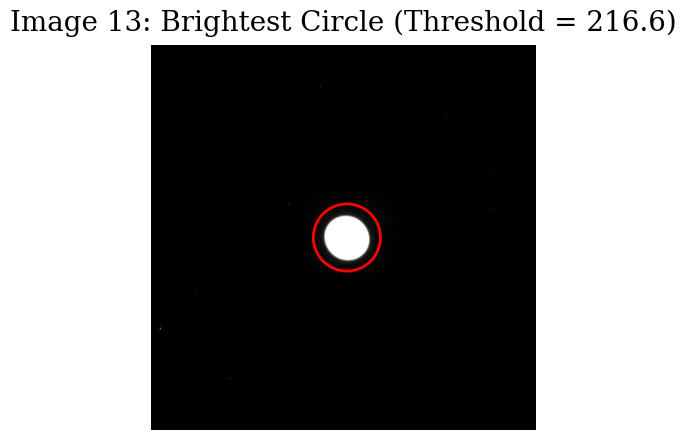

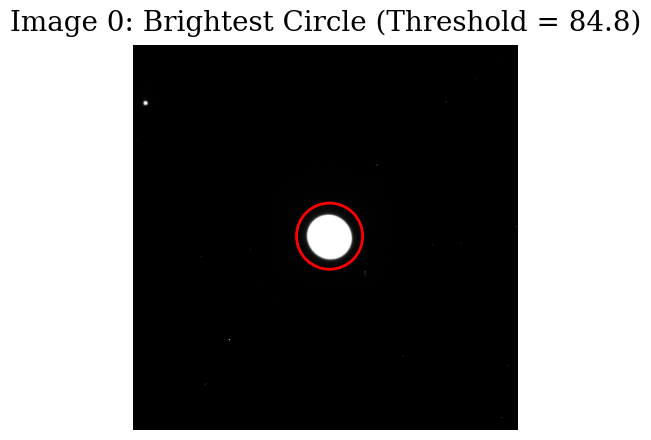

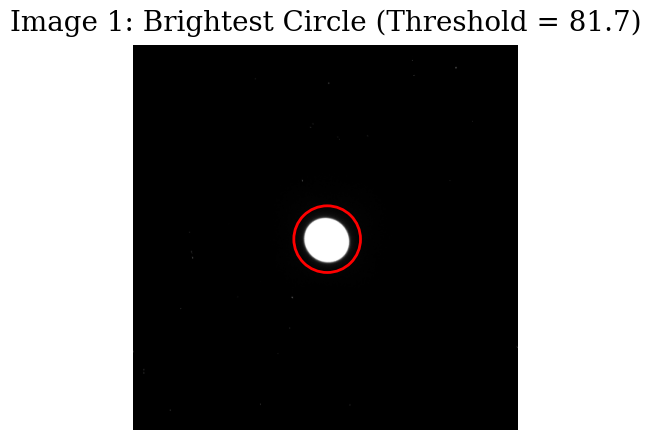

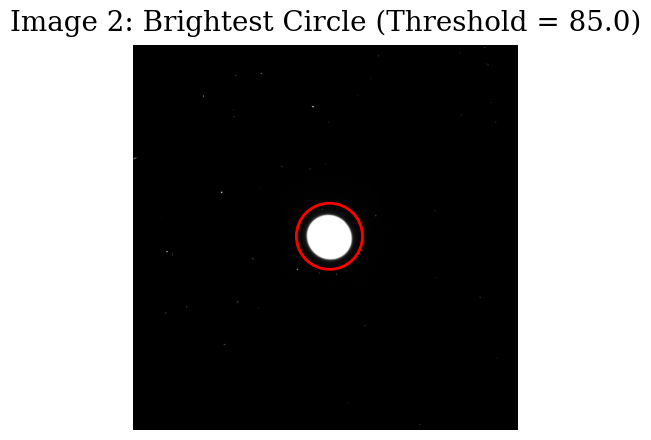

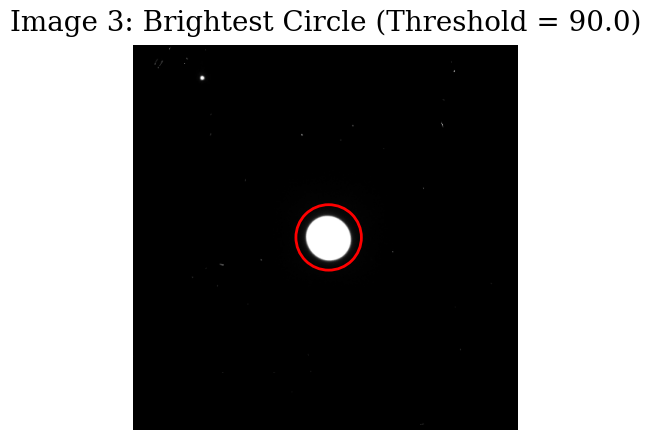

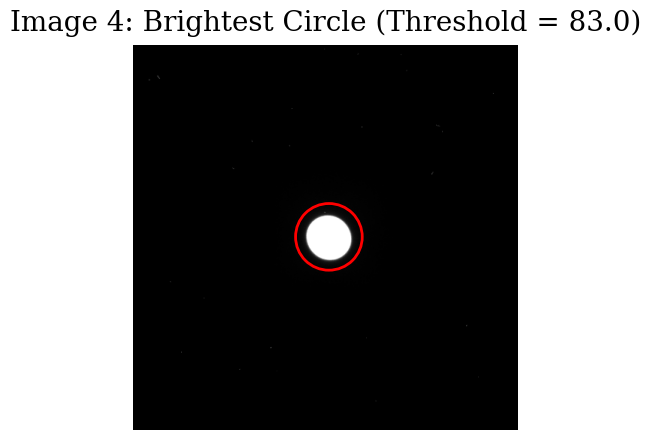

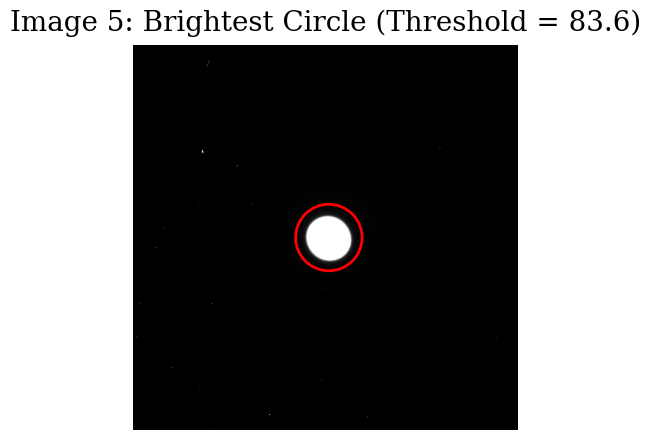

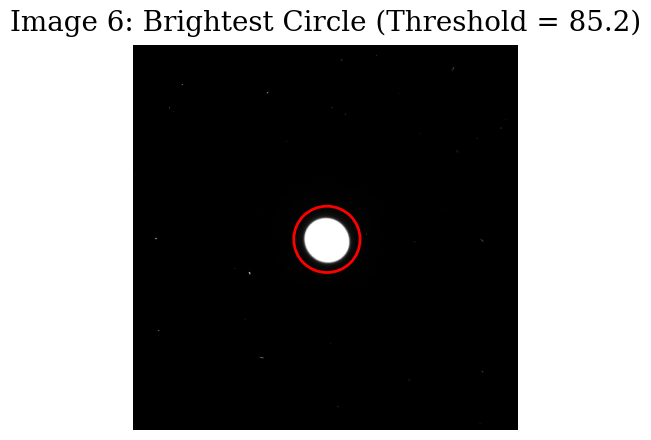

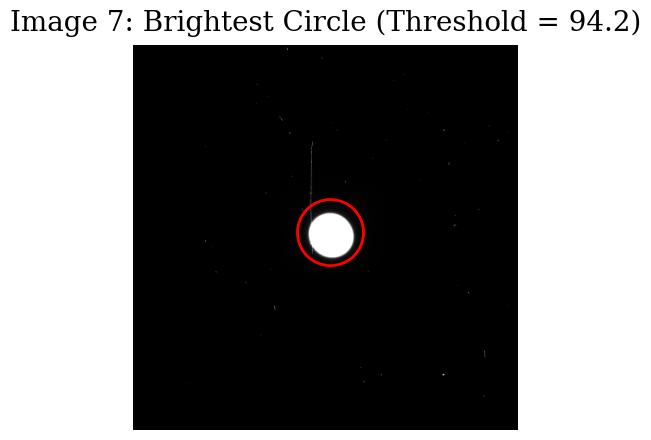

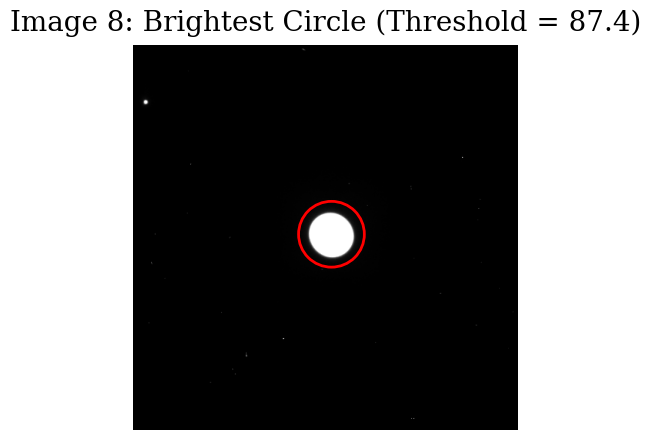

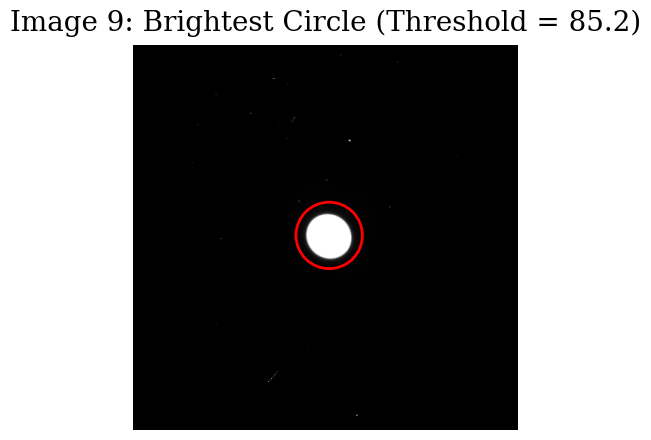

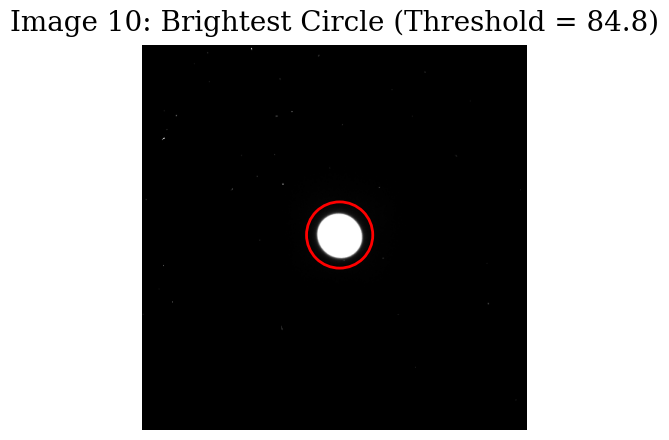

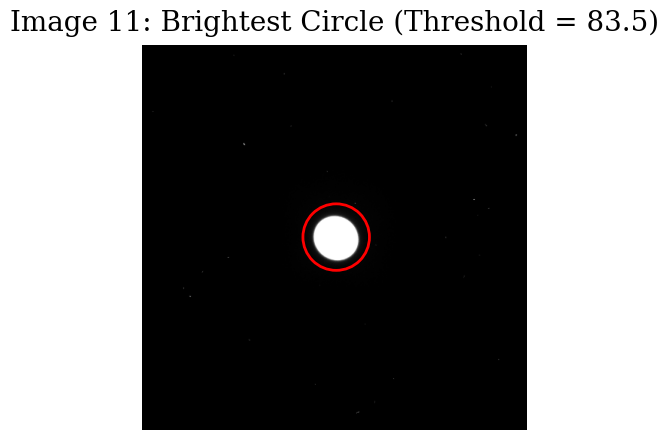

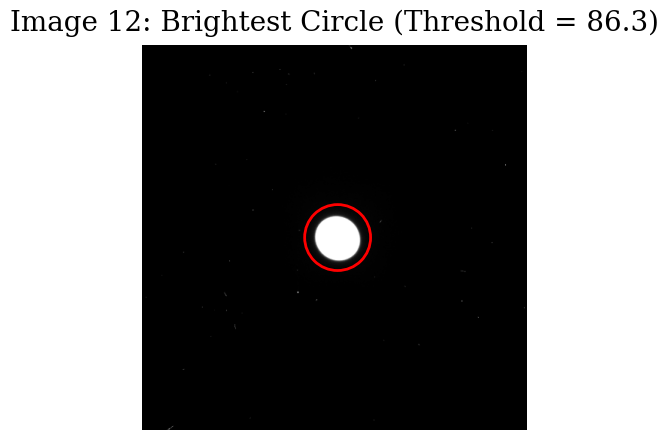

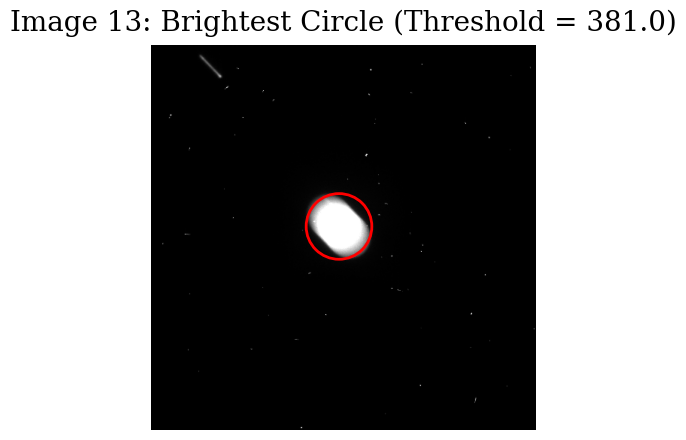

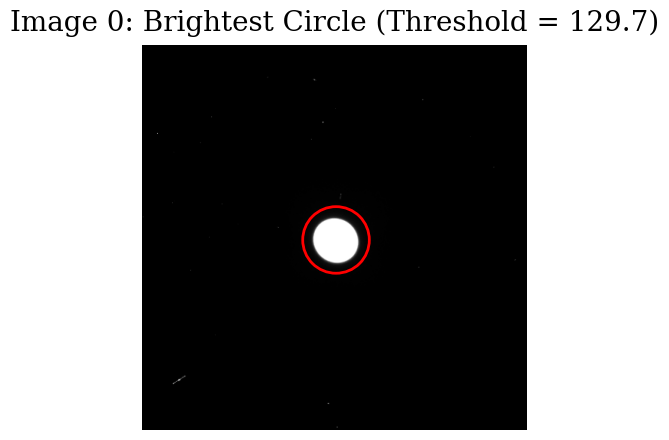

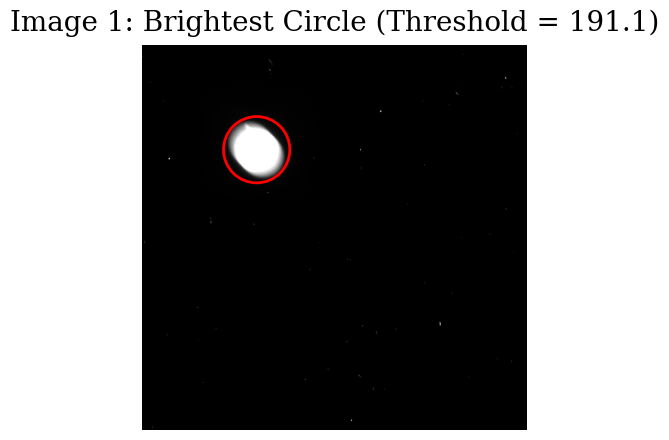

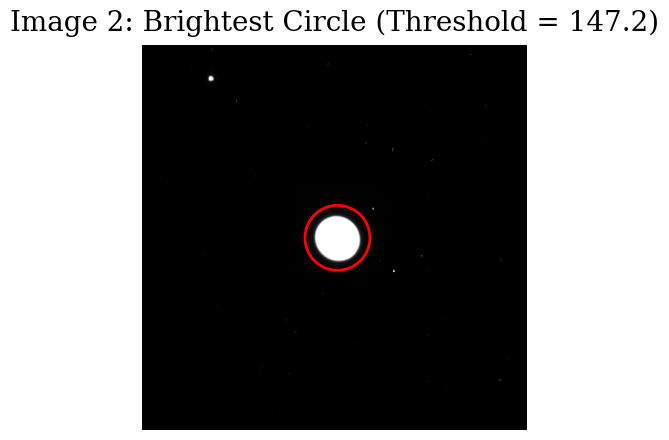

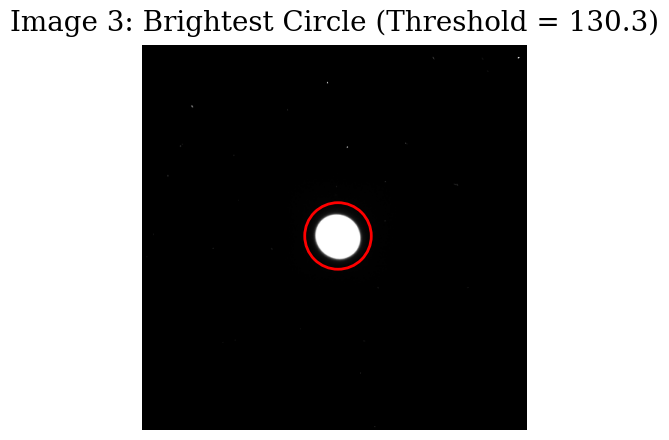

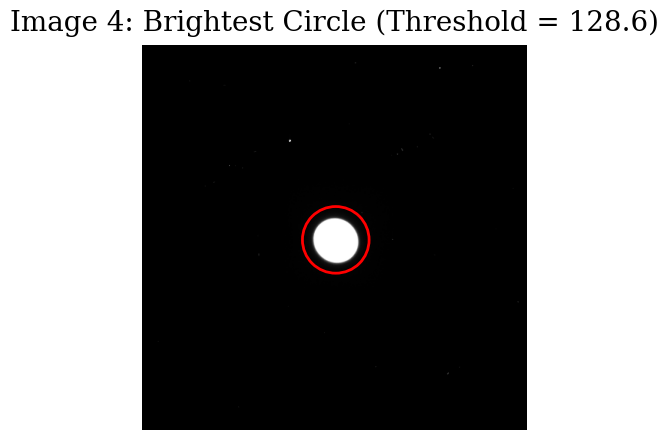

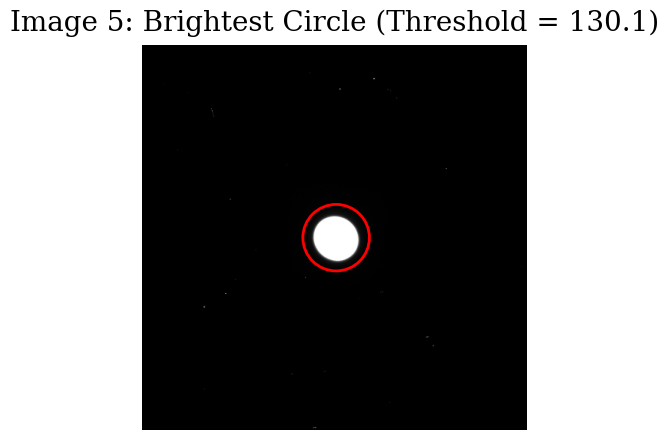

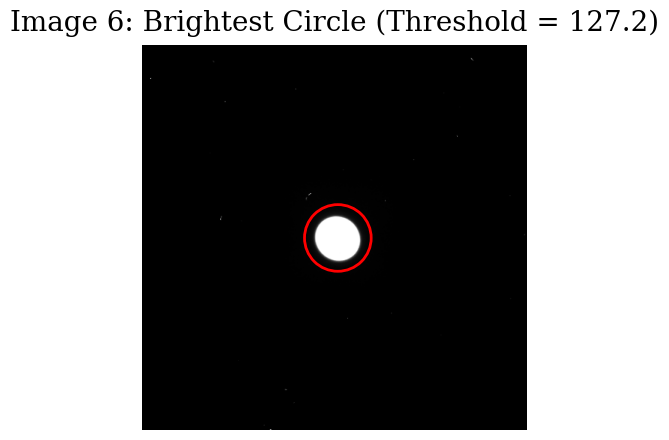

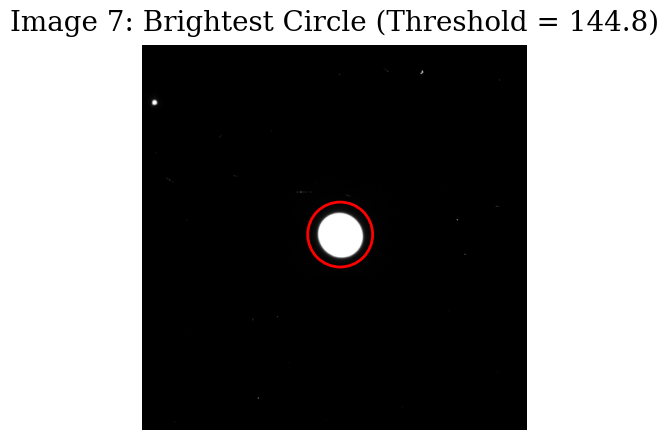

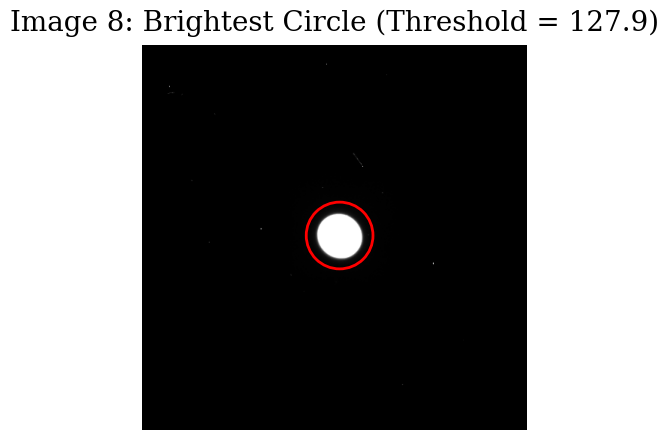

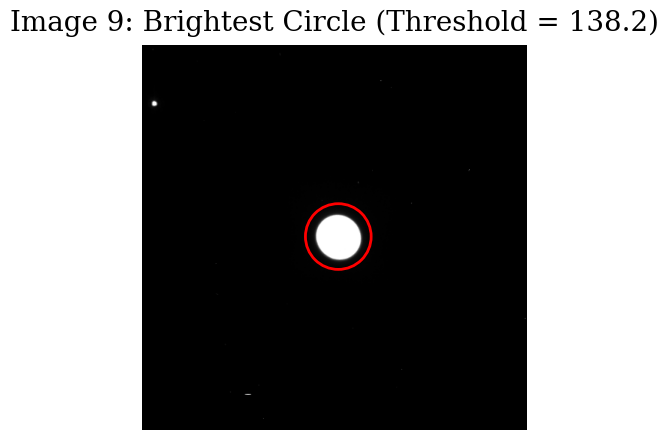

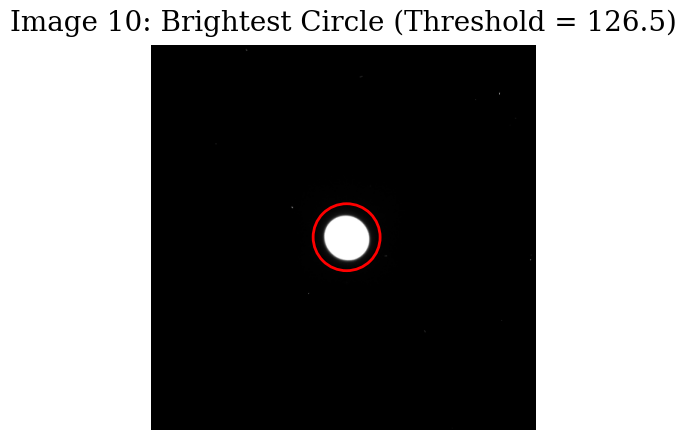

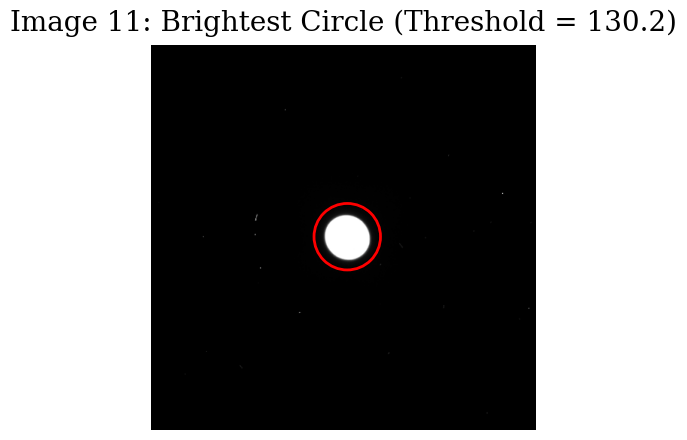

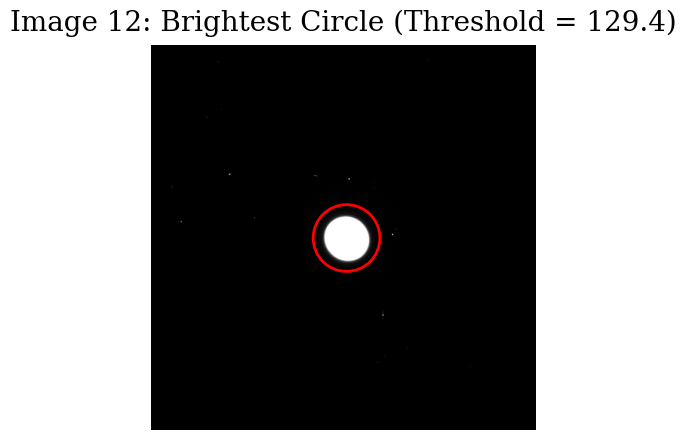

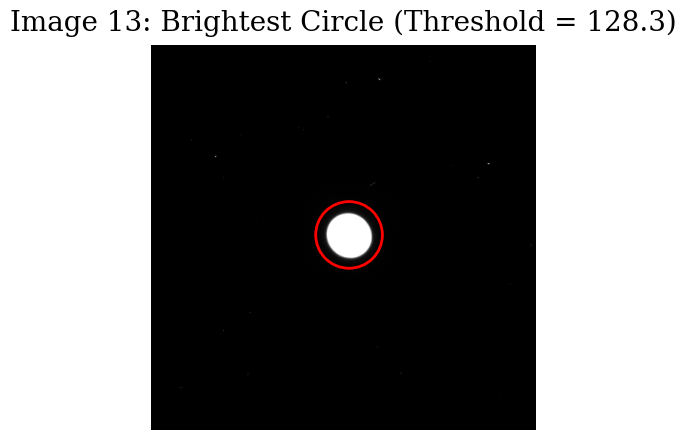

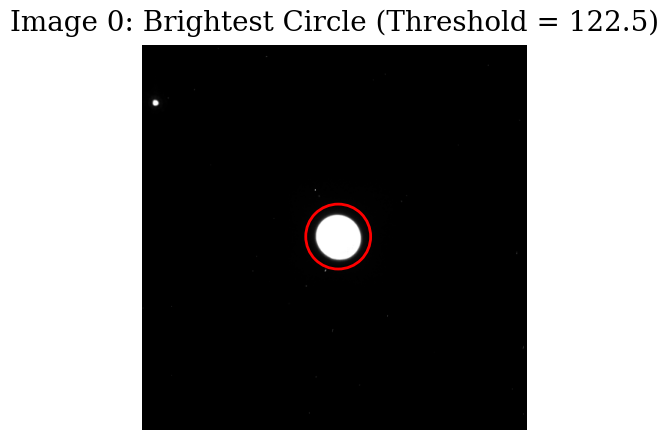

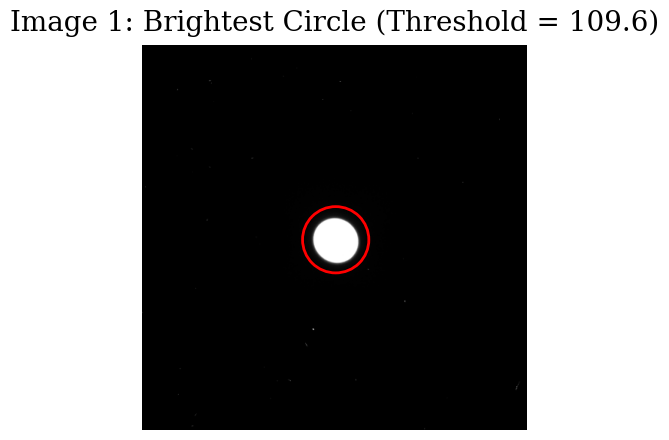

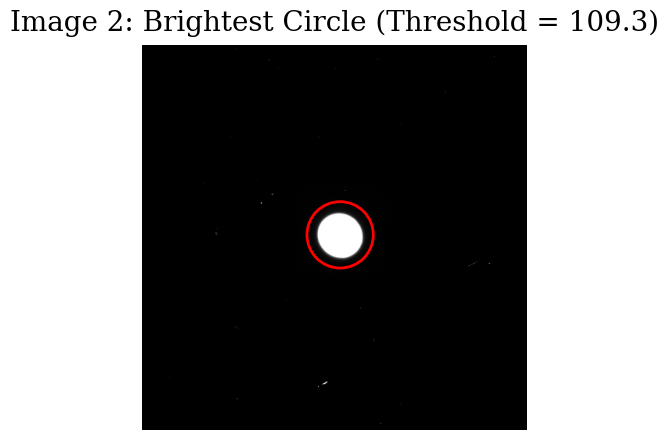

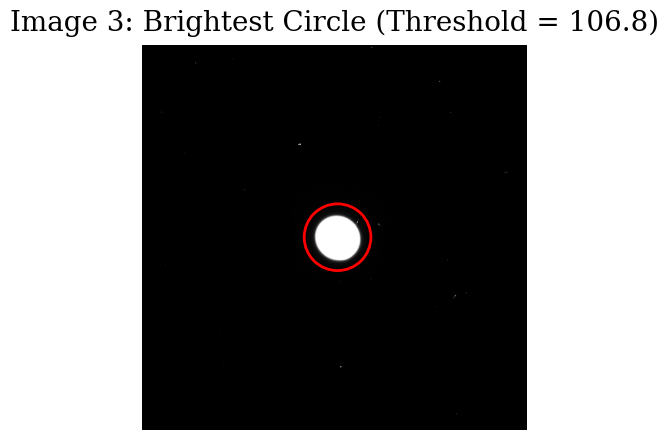

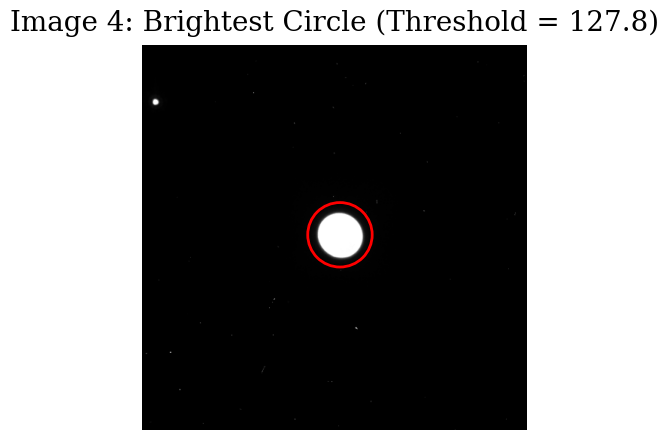

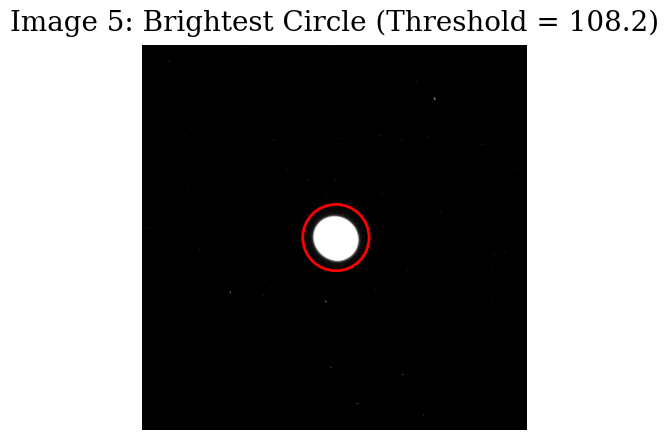

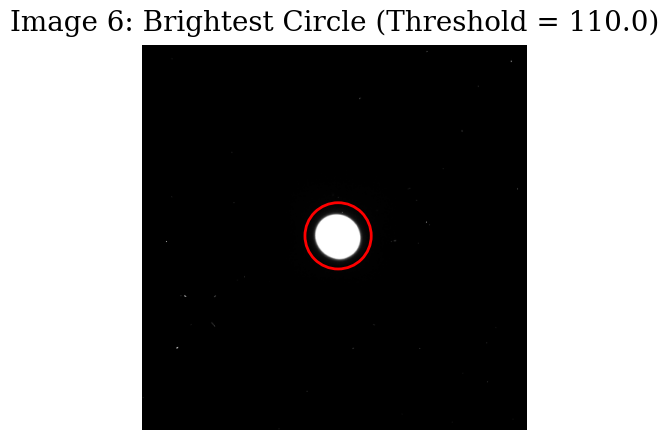

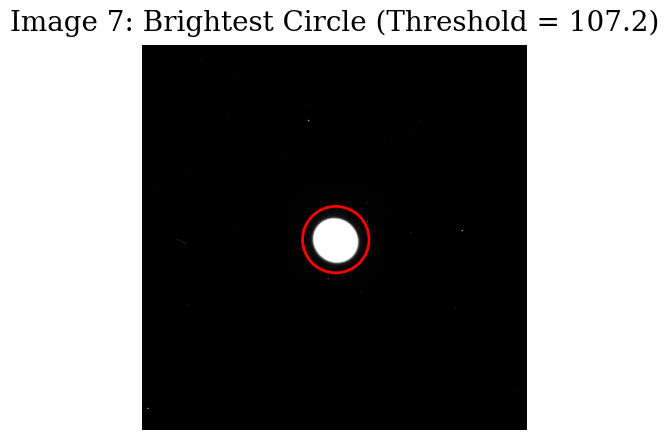

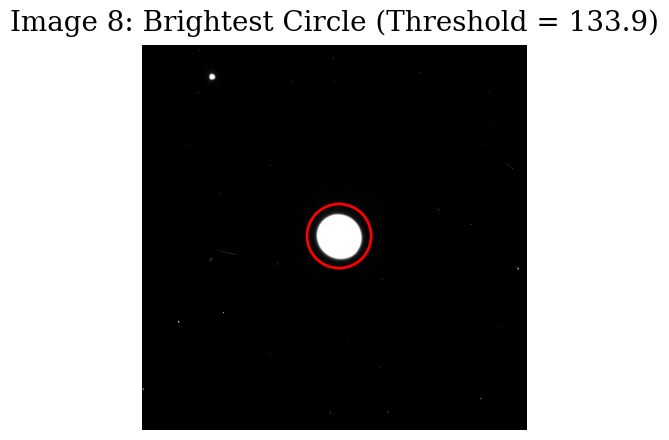

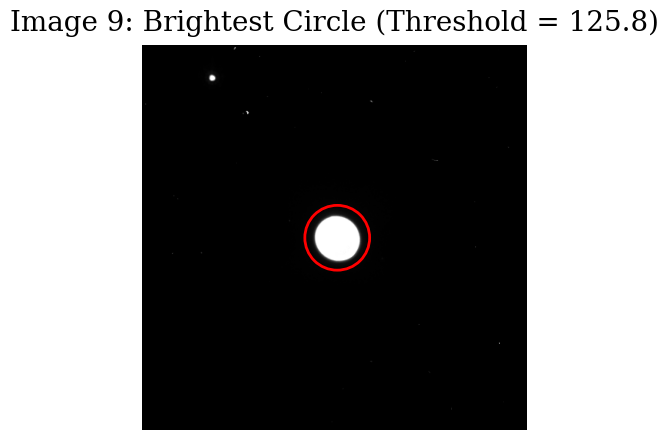

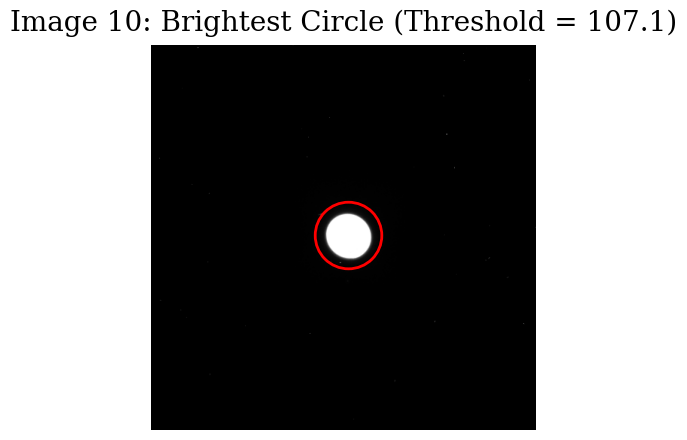

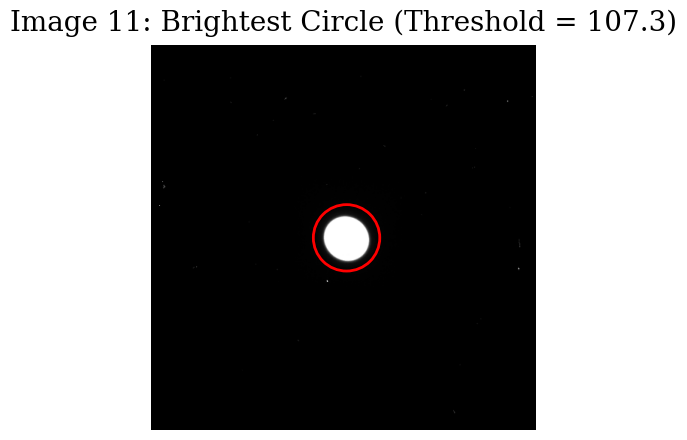

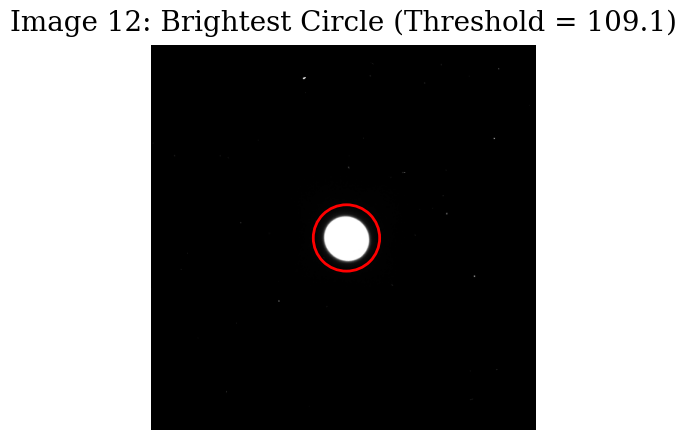

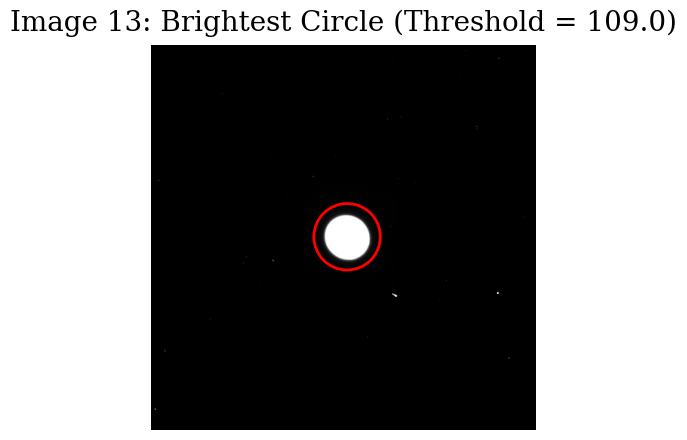

In [9]:
folder =  "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/"
filter_list = ["UVIS2 F467M", "UVIS2 F547M", "UVIS2 F657N", "UVIS2 F763M", "UVIS2 F845M"]
filer_labels = ["F467M", "F547M", "F657N", "F763M", "F845M"]

hst_masterlist, result_masterlist = process_many_filters(folder, filter_list)

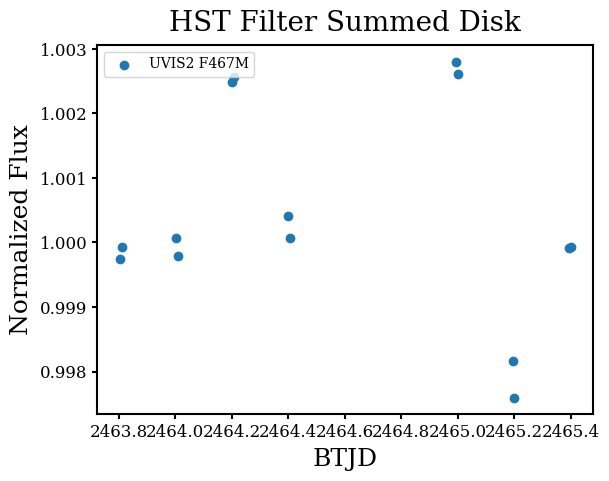

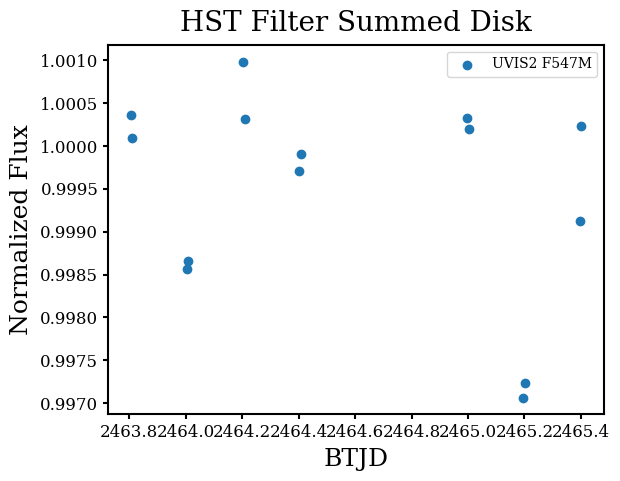

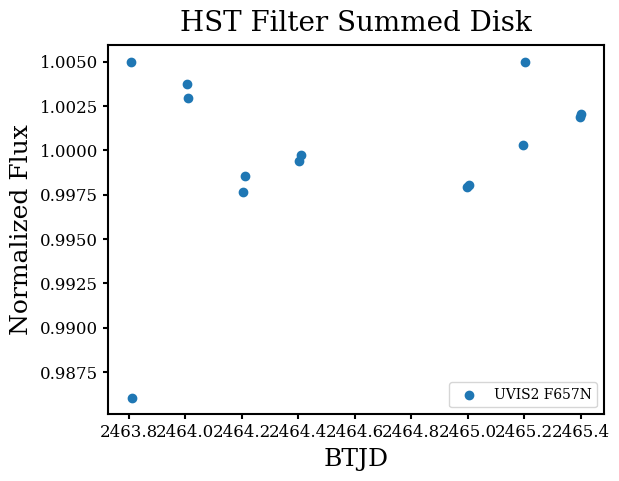

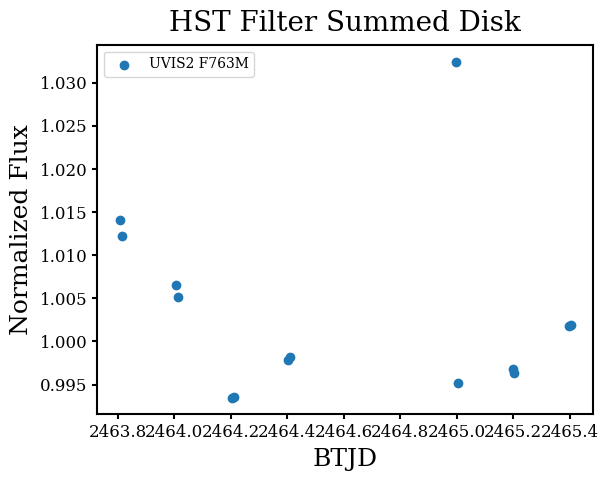

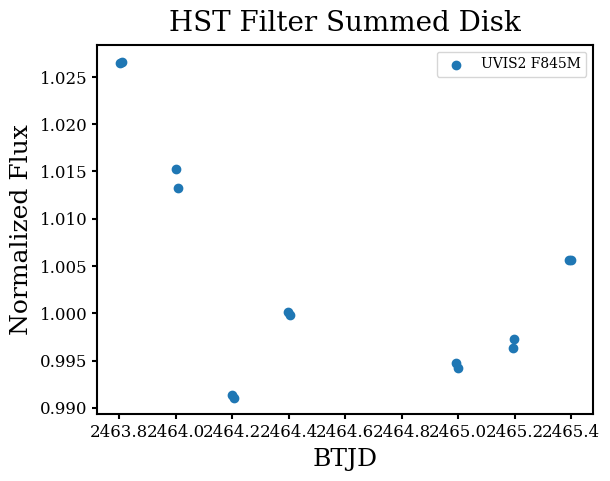

['2021-09-06 06:55:53.390' '2021-09-07 21:22:04.366']


In [10]:
from astropy.time import Time
hst_min_times = []
hst_max_times = []

for ii, filter_name in enumerate(filter_list):
    hst_list = hst_masterlist[ii]
    results = result_masterlist[ii]
    
    hst_times = [entry['mjd'] for entry in hst_list]
    hst_min_times.append(np.min(hst_times))
    hst_max_times.append(np.max(hst_times))
    ra_list = [entry['ra'] for entry in hst_list]
    dec_list = [entry['dec'] for entry in hst_list]
    btjd_times = convert_mjd_list(hst_times, ra_list, dec_list, hst_light_travel_time_correction)

    fluxes = [entry['flux'] for entry in results]
    
    plt.scatter(btjd_times, fluxes / np.nanmedian(fluxes), label=filter_name)
    
    plt.title("HST Filter Summed Disk")
    plt.legend()
    plt.ylabel("Normalized Flux")
    plt.xlabel("BTJD")
    plt.show()

t = Time([np.min(hst_min_times), np.max(hst_max_times)], format='mjd', scale='utc')

print(t.iso)  # ISO 8601 UTC format


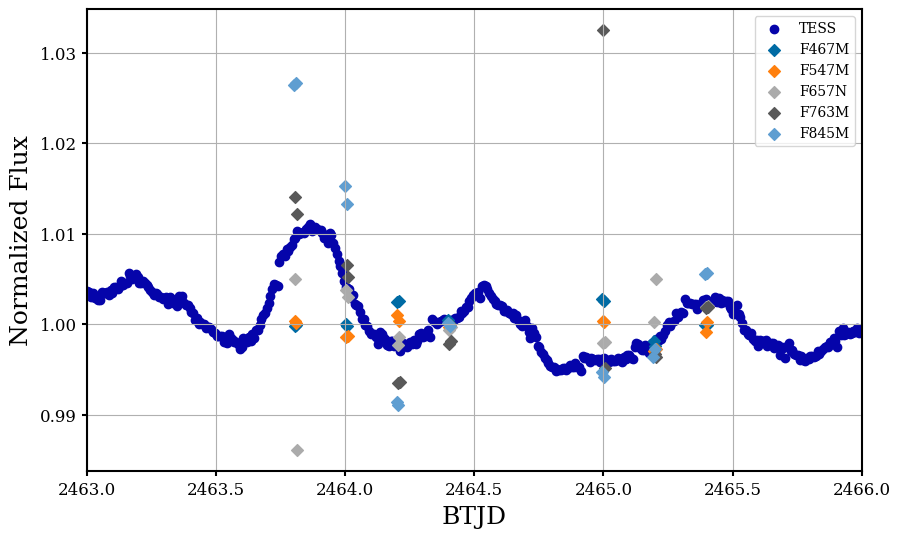

In [17]:
tess_lightcurve = np.loadtxt("/scratch11/ktp9/TESS_SolarSystem/Neptune/s42_cam2_ccd4/results_bps40_pps10/lc_Neptune_s42_cam2_ccd4.txt")
plt.style.use('tableau-colorblind10')
time = tess_lightcurve[0]
flux = tess_lightcurve[1]

# Select the time values in the range [2463:2466] (indices)
t_min = 2463 + 2457000
t_max = 2466 + 2457000

# Create mask selecting time within that range
mask = (time >= t_min) & (time <= t_max)

# Apply mask to both arrays, but only cropping flux where time meets condition
time_cropped = time[mask] - 2457000
flux_cropped = flux[mask]

plt.figure(figsize=(10,6))
plt.grid()

plt.scatter(time_cropped, flux_cropped/np.nanmedian(flux_cropped), label="TESS", color="xkcd:royal blue")

colors = ["xkcd:darkish green", "xkcd:teal green", "xkcd:baby blue", "xkcd:rose", "xkcd:maroon"]

for ii, filter_name in enumerate(filter_list):
    hst_list = hst_masterlist[ii]
    results = result_masterlist[ii]
    
    hst_times = [entry['mjd'] for entry in hst_list]
    ra_list = [entry['ra'] for entry in hst_list]
    dec_list = [entry['dec'] for entry in hst_list]
    btjd_times = convert_mjd_list(hst_times, ra_list, dec_list, hst_light_travel_time_correction)

    fluxes = [entry['flux'] for entry in results]
    
    plt.scatter(btjd_times, fluxes / np.nanmedian(fluxes), label=filer_labels[ii], marker="D") #, color=colors[ii]

plt.ylabel("Normalized Flux")
plt.xlabel("BTJD")
plt.xlim(2463, 2466)
plt.legend()
#plt.savefig("/scratch11/ktp9/TESS_SolarSystem/Neptune/hst_comparison_001.png", dpi=1000)

In [39]:
print(filter_list)

['UVIS2 F845M', 'UVIS2 F657N', 'UVIS2 F467M', 'UVIS2 F763M', 'UVIS2 F547M']
